A toy example for high-dim tensor cross approximation

- License-Identifier: GPL-3.0-only

- This file is part of the TT-sandbox project.

- Copyright © 2025 Idiap Research Institute <contact@idiap.ch>

- Contributor: Teng Xue <teng.xue@idiap.ch>

In [1]:
import numpy as np

from utils import tt_svd_recon, plot_tensor_slices

from tt_cross import cross

In [2]:
cores0 = [
    np.random.rand(1, 5, 4),
    np.random.rand(4, 8, 5),
    np.random.rand(5, 6, 1),
]
tensor = tt_svd_recon(cores0).squeeze()

In [3]:
ranks = [4, 5, 3]
cores = cross(tensor, ranks, n_iter=2, seed=42)
for k, g in enumerate(cores):
    print(f"core {k}: {g.shape}")

# reconstruct the tensor
tensor_hat = tt_svd_recon(cores).squeeze()
print("error:", np.linalg.norm(tensor - tensor_hat))


core 0: (1, 5, 4)
core 1: (4, 8, 5)
core 2: (5, 6, 1)
error: 6.755047963292185e-15


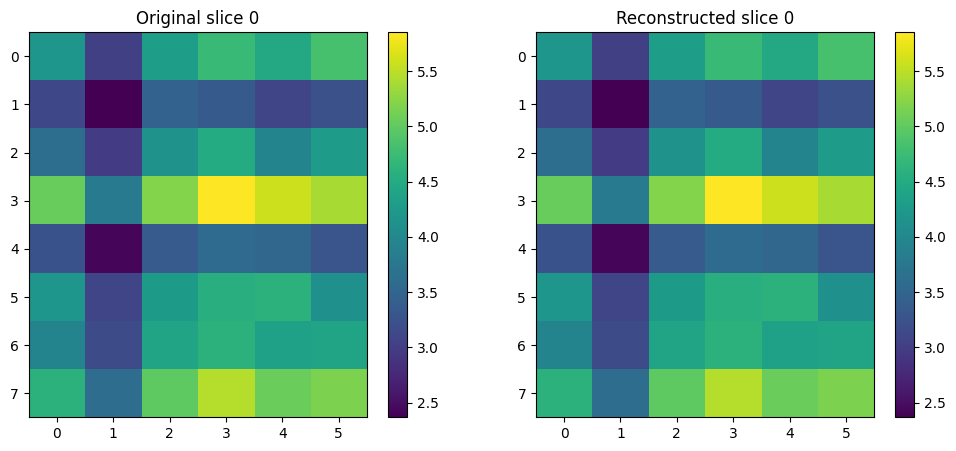

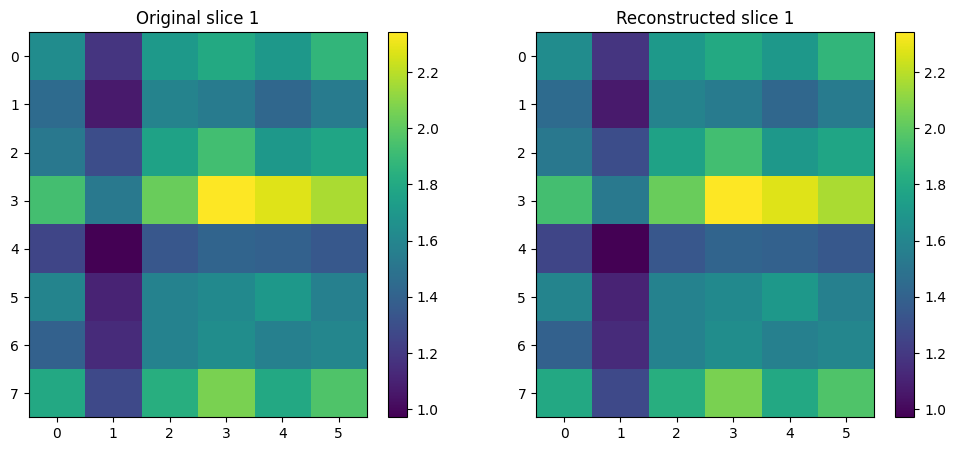

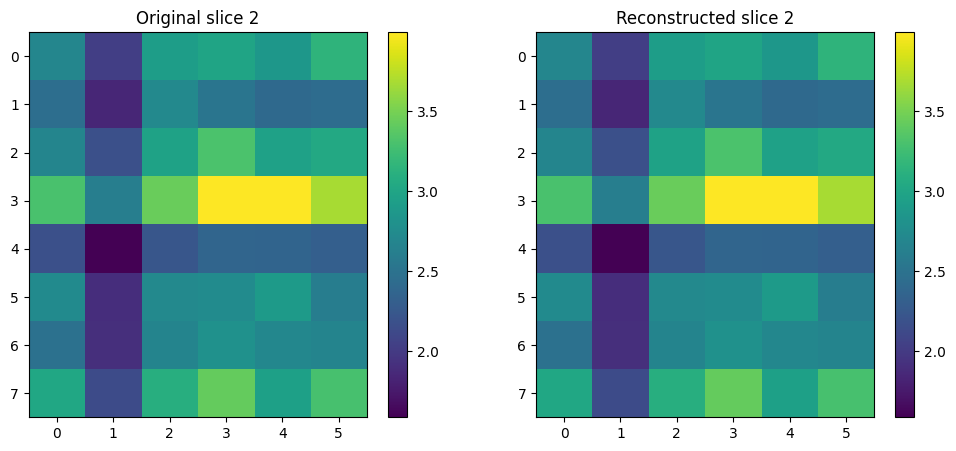

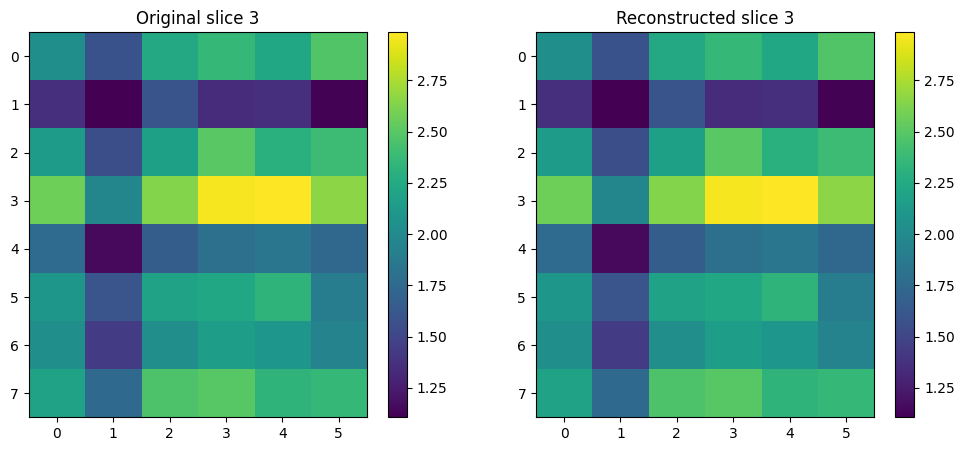

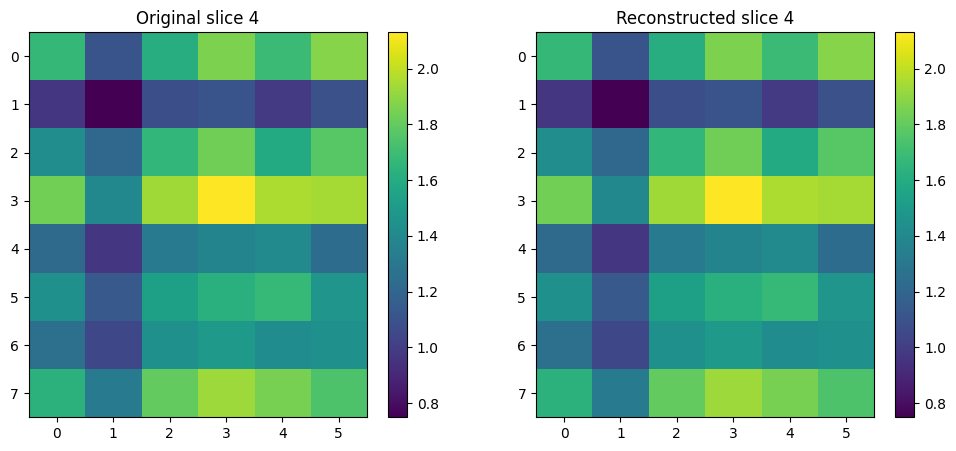

In [4]:
plot_tensor_slices(tensor, tensor_hat)